<a href="https://colab.research.google.com/github/JordanDCunha/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 📦 Install required packages
# =========================
!pip install -q numpy scipy matplotlib pandas scikit-learn mglearn ipython

# =========================
# 📚 Core imports
# =========================
import sys
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
import sklearn
import IPython

# =========================
# 📊 scikit-learn utilities
# =========================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# =========================
# 🧪 Display + plotting setup
# =========================
from IPython.display import display
%matplotlib inline

# =========================
# ✅ Sanity check
# =========================
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", sp.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("mglearn: loaded successfully")


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy: 2.0.2
SciPy: 1.16.3
pandas: 2.2.2
matplotlib: 3.10.0
scikit-learn: 1.6.1
mglearn: loaded successfully


## Chapter 7. Working with Text Data

### Types of Features Recap
- Previously discussed feature types:
  - **Continuous features** (numeric quantities)
  - **Categorical features** (items from a fixed set)
- Introduces a **third major feature type**:
  - **Text data**

---

### Why Text Data Is Important
- Text contains rich information useful for many ML tasks, such as:
  - **Spam detection** (email content)
  - **Opinion analysis** (speeches, tweets)
  - **Customer service classification**:
    - Complaint vs inquiry
    - Routing messages to the right department
    - Enabling automated replies

---

### Characteristics of Text Data
- Usually represented as **strings of characters**
- Text length:
  - Varies significantly between samples
- Fundamentally different from numeric features:
  - Cannot be used directly by most ML algorithms

---

### Key Challenge
- Machine learning models require **numeric input**
- Text must be:
  - **Processed**
  - **Transformed into numeric representations**
- Specialized techniques are needed before applying ML algorithms

---

### What This Chapter Focuses On
- How to:
  - Represent text data numerically
  - Extract meaningful features from raw text
- Preparing text so it can be used effectively in machine learning models


## 7.1 Types of Data Represented as Strings

### Key Idea
- Not all **string features** should be treated as **text**
- How a string should be handled depends on:
  - Its structure
  - The number of unique values
  - Its semantic meaning

---

### Four Types of String Data

#### 1. Categorical Data
- Comes from a **fixed, known list** of values
- Examples:
  - Survey dropdown options (e.g., colors like red, blue, green)
- Characteristics:
  - Small number of unique values
  - Each value represents a distinct category
- Common issues:
  - Typos (e.g., `"blak"` vs `"black"`)
  - Inconsistent spellings
- Best practice:
  - Inspect unique values
  - Consolidate semantically identical entries
  - Encode as categorical variables (e.g., one-hot encoding)

---

#### 2. Free Strings That Can Be Semantically Mapped to Categories
- User-entered text that *roughly* represents categories
- Examples:
  - Favorite colors entered as free text:
    - `"blue"`, `"grey"`, `"midnight blue"`
    - Extremely creative entries (e.g., long descriptive phrases)
- Challenges:
  - Typos, synonyms, creative wording
  - No fixed vocabulary
- Typical solution:
  - Manually define meaningful categories
  - Map common responses to standard categories
  - Use fallback categories like `"multicolored"` or `"other"`
- Important note:
  - This preprocessing is **manual and hard to automate**
  - Avoid free-text input when categorical data is more appropriate

---

#### 3. Structured String Data
- Strings with **internal structure**, but not free text
- Examples:
  - Names
  - Addresses
  - Dates
  - Phone numbers
  - IDs
- Characteristics:
  - Meaning depends heavily on context and domain
- Limitation:
  - No general-purpose solution
  - Handling these is **application-specific**
  - Outside the scope of this book

---

#### 4. Text Data (Freeform Text)
- Natural language text made of words and sentences
- Examples:
  - Emails
  - Tweets
  - Chat logs
  - Reviews
  - Books, Wikipedia articles
- Characteristics:
  - Variable length
  - Rich semantic information
- Common assumptions:
  - All documents are in the same language (e.g., English)
- Terminology:
  - **Corpus**: the full collection of text data
  - **Document**: a single text sample
- This is the **main focus of text analysis and NLP**

---

### Takeaway
- String features are **not automatically text features**
- Correctly identifying the type of string data is critical
- Misclassification leads to poor feature representations and model performance
Ca

## 7.2 Example Application: Sentiment Analysis of Movie Reviews

### Goal of the Example
- Demonstrate **text classification** using real-world data
- Task: predict whether a movie review is **positive** or **negative**
- This is a **binary supervised classification problem**

---

### Dataset Overview (IMDb Reviews)
- Source: IMDb movie reviews
- Collected by: Andrew Maas (Stanford)
- Each review includes:
  - Text content
  - Sentiment label (positive or negative)

---

### Label Construction
- Original IMDb ratings range from **1 to 10**
- Labels are simplified:
  - **Positive** → rating ≥ 7
  - **Negative** → rating ≤ 4
  - Neutral reviews are **excluded**


In [2]:
!wget -nc http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz -P data
!tar xzf data/aclImdb_v1.tar.gz --skip-old-files -C data


File ‘data/aclImdb_v1.tar.gz’ already there; not retrieving.



### Dataset Folder Structure
- Reviews are stored as **individual text files**
- Organized into folders:
  - `train/pos` → positive training reviews
  - `train/neg` → negative training reviews
  - `test/pos` → positive test reviews
  - `test/neg` → negative test reviews
- An additional `unsup` folder exists but is **not used**


In [3]:
!tree -dL 2 data/aclImdb


/bin/bash: line 1: tree: command not found


### Removing Unused Data
- The `unsup` folder contains **unlabeled reviews**
- It is not needed for supervised learning
- We remove it to avoid confusion


In [4]:
!rm -r data/aclImdb/train/unsup


### Loading the Training Data
- scikit-learn provides `load_files`
- Each subfolder name becomes a **class label**
- Output:
  - `text_train`: list of review texts
  - `y_train`: numeric sentiment labels


In [5]:
from sklearn.datasets import load_files

reviews_train = load_files("data/aclImdb/train/")
text_train, y_train = reviews_train.data, reviews_train.target

print("type of text_train:", type(text_train))
print("length of text_train:", len(text_train))
print("sample review:\n", text_train[6])


type of text_train: <class 'list'>
length of text_train: 25000
sample review:
 b"This movie has a special way of telling the story, at first i found it rather odd as it jumped through time and I had no idea whats happening.<br /><br />Anyway the story line was although simple, but still very real and touching. You met someone the first time, you fell in love completely, but broke up at last and promoted a deadly agony. Who hasn't go through this? but we will never forget this kind of pain in our life. <br /><br />I would say i am rather touched as two actor has shown great performance in showing the love between the characters. I just wish that the story could be a happy ending."


### Cleaning the Text
- Reviews contain HTML tags such as `<br />`
- These do not help classification
- We remove them as basic text preprocessing


In [6]:
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]


### Class Balance in Training Data
- Dataset was constructed to be **balanced**
- Equal number of positive and negative reviews
- This simplifies evaluation and interpretation


In [7]:
import numpy as np
print("Samples per class (training):", np.bincount(y_train))


Samples per class (training): [12500 12500]


### Loading the Test Data
- Test data follows the same structure as training data
- Used only for **final evaluation**
- Must undergo the **same preprocessing steps**


In [8]:
reviews_test = load_files("data/aclImdb/test/")
text_test, y_test = reviews_test.data, reviews_test.target

print("Number of documents in test data:", len(text_test))
print("Samples per class (test):", np.bincount(y_test))

text_test = [doc.replace(b"<br />", b" ") for doc in text_test]


Number of documents in test data: 25000
Samples per class (test): [12500 12500]


### Final Task Definition
- Input: a movie review (text)
- Output: sentiment label (positive or negative)
- Challenge:
  - Text is not numeric
  - Machine learning models require numbers
- Next step:
  - Convert text into **numeric features**


## 7.3 Representing Text Data as a Bag of Words

### What is Bag-of-Words (BoW)?
- A simple and widely used text representation
- Ignores:
  - Word order
  - Sentence structure
  - Grammar
- Keeps:
  - How often each word appears in a document

---

### Key Idea
- Each document → vector of word counts
- Each unique word → one feature
- Word order does **not** matter


## 7.3 Representing Text Data as a Bag of Words

### What is Bag-of-Words (BoW)?
- A simple and widely used text representation
- Ignores:
  - Word order
  - Sentence structure
  - Grammar
- Keeps:
  - How often each word appears in a document

---

### Key Idea
- Each document → vector of word counts
- Each unique word → one feature
- Word order does **not** matter


### Bag-of-Words Construction Steps
1. **Tokenization**
   - Split text into words (tokens)
   - Typically split on whitespace and punctuation

2. **Vocabulary Building**
   - Collect all unique words in the corpus
   - Assign each word an index

3. **Encoding**
   - For each document:
     - Count occurrences of each vocabulary word


### Resulting Representation
- One feature per word in the vocabulary
- One row per document
- Produces a **high-dimensional sparse matrix**
- Word order is completely discarded


## 7.3.1 Applying Bag-of-Words to a Toy Dataset

### Purpose
- Understand Bag-of-Words mechanics
- Use a tiny dataset for clarity


In [9]:
bards_words = [
    "The fool doth think he is wise,",
    "but the wise man knows himself to be a fool"
]


### Using CountVectorizer
- scikit-learn implementation of Bag-of-Words
- Acts as a **transformer**
- Performs:
  - Tokenization
  - Vocabulary construction


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()
vect.fit(bards_words)


CountVectorizer()

### Inspecting the Vocabulary
- Vocabulary maps words → feature indices
- Stored in `vocabulary_`


In [11]:
print("Vocabulary size:", len(vect.vocabulary_))
print("Vocabulary content:\n", vect.vocabulary_)


Vocabulary size: 13
Vocabulary content:
 {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


### Transforming Text into Features
- `transform()` converts text → numeric vectors
- Output is a **sparse matrix**


In [12]:
bag_of_words = vect.transform(bards_words)
print("bag_of_words:", repr(bag_of_words))


bag_of_words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


### Why Sparse Matrices?
- Most words do not appear in most documents
- Sparse storage:
  - Saves memory
  - Improves performance


In [13]:
print("Dense representation:\n", bag_of_words.toarray())


Dense representation:
 [[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


### Interpreting the Feature Vectors
- Rows → documents
- Columns → vocabulary words
- Values → word counts
- Example:
  - "fool", "wise", "the" appear in both documents


## 7.3.2 Bag-of-Words for Movie Reviews

### Applying BoW to IMDb Dataset
- Training data already loaded as:
  - `text_train`
  - `y_train`
- Now convert reviews into numeric features


In [14]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)

print("X_train:\n", repr(X_train))


X_train:
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


### Observations
- Shape: `25000 × 74849`
- ~75k unique words (features)
- Extremely high-dimensional


### Inspecting the Vocabulary
- `get_feature_names()` returns:
  - Index-aligned list of vocabulary words


In [15]:
feature_names = vect.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 20 features:\n", feature_names[:20])
print("Features 20010–20030:\n", feature_names[20010:20030])
print("Every 2000th feature:\n", feature_names[::2000])


Number of features: 74849
First 20 features:
 ['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
Features 20010–20030:
 ['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
Every 2000th feature:
 ['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


### Vocabulary Issues
- Many tokens are:
  - Numbers
  - Rare words
  - Misspellings
- Singular/plural forms treated as different features
- Can reduce usefulness and increase dimensionality


### Training a Classifier
- Data is:
  - High-dimensional
  - Sparse
- Linear models work best
- Use **Logistic Regression**


In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

scores = cross_val_score(LogisticRegression(), X_train, y_train, cv=5)
print("Mean cross-validation accuracy:", np.mean(scores))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Mean cross-validation accuracy: 0.8818400000000001


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Hyperparameter Tuning
- Logistic Regression regularization controlled by `C`
- Use GridSearchCV


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best CV score:", grid.best_score_)
print("Best parameters:", grid.best_params_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best CV score: 0.889
Best parameters: {'C': 0.1}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluating on Test Data
- Transform test data using same vocabulary
- Measure generalization performance


In [18]:
X_test = vect.transform(text_test)
print("Test score:", grid.score(X_test, y_test))


Test score: 0.87888


### Improving Feature Quality
- Default token pattern includes numbers
- Rare words add noise
- Solution:
  - Remove words appearing in very few documents


### `min_df` Parameter
- `min_df = 5`
- Only keep words appearing in ≥ 5 documents
- Reduces dimensionality


In [19]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)

print("X_train with min_df:", repr(X_train))


X_train with min_df: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


### Effects of min_df
- Features reduced from ~75k → ~27k
- Removes rare & uninformative tokens
- Faster training


In [20]:
feature_names = vect.get_feature_names_out()

print("First 50 features:\n", feature_names[:50])
print("Features 20010–20030:\n", feature_names[20010:20030])
print("Every 700th feature:\n", feature_names[::700])


First 50 features:
 ['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Features 20010–20030:
 ['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Every 700th feature:
 ['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger' 'swastika' 'thrusting' 't

### Re-evaluating the Model
- Same grid search as before
- Expect similar accuracy, fewer features


In [21]:
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best cross-validation score:", grid.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best cross-validation score: 0.88748


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Final Notes
- Unknown words in test data are ignored
- Usually not a problem for classification
- Possible extension:
  - Count out-of-vocabulary words manually


## 7.4 Stopwords

### What Are Stopwords?
- Words that appear **very frequently**
- Usually carry **little semantic meaning**
- Examples:
  - "the", "is", "and", "to", "of"

---

### Why Remove Stopwords?
- Reduce uninformative features
- Potentially improve:
  - Model performance
  - Interpretability


## 7.4 Stopwords

### What Are Stopwords?
- Words that appear **very frequently**
- Usually carry **little semantic meaning**
- Examples:
  - "the", "is", "and", "to", "of"

---

### Why Remove Stopwords?
- Reduce uninformative features
- Potentially improve:
  - Model performance
  - Interpretability


### Two Common Approaches
1. **Use a predefined stopword list**
   - Language-specific
   - Manually curated

2. **Discard overly frequent words**
   - Based on document frequency (`max_df`)
   - Data-driven


### Built-in Stopwords in scikit-learn
- scikit-learn provides:
  - A built-in English stopword list
- Available in:
  - `sklearn.feature_extraction.text`


In [22]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("Number of stop words:", len(ENGLISH_STOP_WORDS))
print("Every 10th stopword:\n", list(ENGLISH_STOP_WORDS)[::10])


Number of stop words: 318
Every 10th stopword:
 ['yourself', 'ours', 'mill', 'of', 'thin', 'that', 'upon', 'fifteen', 'top', 'will', 'as', 'only', 'along', 'sometime', 'describe', 'before', 'almost', 'therein', 'she', 'nine', 'part', 'full', 'why', 'take', 'found', 'always', 'however', 'is', 'ie', 'can', 'see', 'fifty']


### Observations
- Total stopwords: 318
- Removing stopwords:
  - Can only reduce features by at most this number
- Might still help performance slightly


### Applying Stopwords in CountVectorizer
- Use `stop_words="english"`
- Uses scikit-learn's built-in list
- Can also pass a custom list


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(
    min_df=5,
    stop_words="english"
).fit(text_train)

X_train = vect.transform(text_train)

print("X_train with stop words:\n", repr(X_train))


X_train with stop words:
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


### Effect on Feature Space
- Feature count reduced:
  - From 27,271 → 26,966
- Removed ~305 features
- Not all stopwords appeared in the dataset


### Re-evaluating Model Performance
- Same Logistic Regression setup
- Same parameter grid
- Evaluate via GridSearchCV


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best cross-validation score:", grid.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best cross-validation score: 0.88296


### Results & Interpretation
- Accuracy slightly decreased (≈ 0.88)
- Difference is small and not concerning
- Removing ~300 features out of 27k:
  - Has limited impact


### When Are Stopword Lists Useful?
- More helpful for:
  - Small datasets
  - Low-resource settings
- Large datasets often:
  - Let the model learn which words matter


### Alternative: Removing Very Frequent Words
- Use `max_df` in CountVectorizer
- Removes words appearing in too many documents
- Data-driven stopword removal

💡 Exercise:
Try different `max_df` values and observe:
- Feature count
- Cross-validation accuracy


## 7.5 Rescaling the Data with TF–IDF

### Motivation
- Instead of **dropping words**, rescale them by **informativeness**
- Common approach: **tf–idf (term frequency–inverse document frequency)**

---

### Intuition Behind TF–IDF
- High weight if a word:
  - Appears **often in one document**
  - Appears in **few documents overall**
- Such words are likely:
  - Descriptive
  - Discriminative


### TF–IDF in scikit-learn
Two implementations:
1. **TfidfTransformer**
   - Takes output of `CountVectorizer`
   - Applies tf–idf scaling

2. **TfidfVectorizer**
   - Combines:
     - Bag-of-words
     - TF–IDF rescaling


### TF–IDF Formula (Conceptual)
- tf(w, d): frequency of word w in document d
- idf(w): inverse document frequency

Key quantities:
- N: total number of documents
- N_w: number of documents containing word w

---

### Additional Processing
- Applies **L2 normalization**
- Each document vector:
  - Has Euclidean length = 1
- Prevents longer documents from dominating


### Why Use a Pipeline?
- TF–IDF depends on **training data statistics**
- To avoid data leakage:
  - Must compute tf–idf **inside cross-validation**
- Use `Pipeline` + `GridSearchCV`


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(
    TfidfVectorizer(min_df=5),
    LogisticRegression()
)

param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)

print("Best cross-validation score: {:.2f}".format(grid.best_score_))


Best cross-validation score: 0.89


### Result
- Best cross-validation accuracy: ~0.89
- TF–IDF **did not improve performance**
- Comparable to bag-of-words results


### Inspecting TF–IDF Feature Importance
- TF–IDF is **unsupervised**
- "Important" ≠ predictive for sentiment
- Measures document distinctiveness only


In [26]:
import numpy as np

vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]

X_train = vectorizer.transform(text_train)

# Maximum tf–idf value per feature
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()

feature_names = np.array(vectorizer.get_feature_names_out())


In [27]:
print("Features with lowest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[:20]]
))

print("Features with highest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[-20:]]
))


Features with lowest tfidf:
['suplexes' 'gauche' 'hypocrites' 'oncoming' 'songwriting' 'galadriel'
 'emerald' 'mclaughlin' 'sylvain' 'oversee' 'cataclysmic' 'pressuring'
 'uphold' 'thieving' 'inconsiderate' 'ware' 'denim' 'reverting' 'booed'
 'spacious']
Features with highest tfidf:
['gadget' 'sucks' 'zatoichi' 'demons' 'lennon' 'bye' 'dev' 'weller'
 'sasquatch' 'botched' 'xica' 'darkman' 'woo' 'casper' 'doodlebops'
 'smallville' 'wei' 'scanners' 'steve' 'pokemon']


### Observations: TF–IDF Extremes

Low TF–IDF:
- Very common words
- Or rare words in long documents

High TF–IDF:
- Often **proper nouns**
- Movie- or franchise-specific terms
  - e.g., "homer", "titanic", "timon"


### Interpretation
- High TF–IDF words:
  - Identify specific movies or characters
  - Not necessarily sentiment-related
- TF–IDF highlights:
  - Distinctiveness
  - Not class relevance


### Inverse Document Frequency (IDF)
- Measures how common a word is across documents
- Low IDF:
  - Very frequent
  - Less informative


In [28]:
sorted_by_idf = np.argsort(vectorizer.idf_)

print("Features with lowest idf:\n{}".format(
    feature_names[sorted_by_idf[:100]]
))


Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


### Observations: Low-IDF Words
- Mostly stopwords:
  - "the", "and", "of", "to"
- Domain-specific frequent words:
  - "movie", "film", "story", "time"
- Sentiment words also frequent:
  - "good", "great", "bad"


### Key Takeaways
- TF–IDF downweights:
  - Common words
  - Even sentiment-heavy words
- Frequency ≠ usefulness for prediction
- TF–IDF alone is not sentiment-aware


## 7.6 Investigating Model Coefficients

### Goal
- Understand **what the logistic regression model learned**
- Inspect which words:
  - Push predictions toward **negative**
  - Push predictions toward **positive**

---

### Why Coefficients Matter
- Logistic regression is a **linear model**
- Each word feature has:
  - A **coefficient**
  - Direction (+ / −)
  - Magnitude (importance)


## 7.6 Investigating Model Coefficients

### Goal
- Understand **what the logistic regression model learned**
- Inspect which words:
  - Push predictions toward **negative**
  - Push predictions toward **positive**

---

### Why Coefficients Matter
- Logistic regression is a **linear model**
- Each word feature has:
  - A **coefficient**
  - Direction (+ / −)
  - Magnitude (importance)


### Model Used
- TF–IDF features
- Logistic Regression
- Best model obtained from:
  - `GridSearchCV`
  - Stored in `grid.best_estimator_`


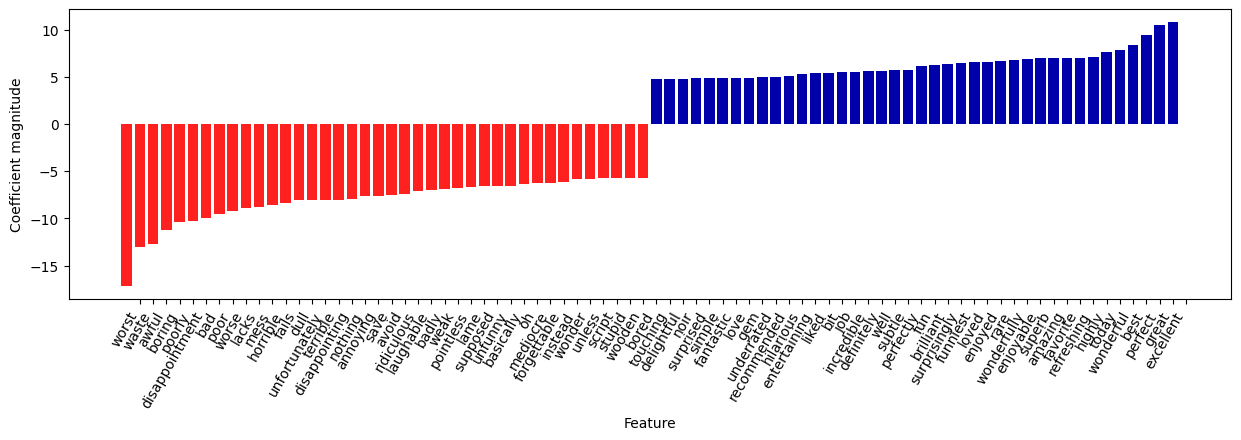

In [29]:
import mglearn

mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_,
    feature_names,
    n_top_features=40
)


### Interpreting the Visualization

- **Left side (negative coefficients)**:
  - Words indicative of *negative reviews*
- **Right side (positive coefficients)**:
  - Words indicative of *positive reviews*

- Bar length = strength of influence


### Examples: Negative Review Indicators
- "worst"
- "waste"
- "disappointment"
- "laughable"

These words strongly push predictions toward:
➡️ **Negative sentiment**


### Examples: Positive Review Indicators
- "excellent"
- "wonderful"
- "enjoyable"
- "refreshing"

These words strongly push predictions toward:
➡️ **Positive sentiment**


### Ambiguous or Context-Dependent Words
Some coefficients are less obvious:
- "bit"
- "job"
- "today"

Likely explanations:
- Appear in common phrases:
  - "good job"
  - "best today"
- Model captures **correlations**, not grammar


### Key Takeaways
- TF–IDF + Logistic Regression:
  - Produces **interpretable models**
- Coefficients reveal:
  - What words matter
  - In which direction
- Interpretation still requires:
  - Human judgment
  - Context awareness


## 7.7 Bag-of-Words with More Than One Word (n-Grams)

### Motivation
- Standard bag-of-words:
  - Ignores **word order**
  - Loses **context**
- Example with opposite meanings but same unigram counts:
  - "it's bad, not good at all"
  - "it's good, not bad at all"


### Key Idea: n-Grams
- Capture **local context** by including sequences of words
- Types of n-grams:
  - **Unigrams** → single words
  - **Bigrams** → two consecutive words
  - **Trigrams** → three consecutive words
- General term: **n-grams**


### How n-Grams Are Controlled in scikit-learn
- Controlled via `ngram_range`
- Format:
  - `(min_n, max_n)`
- Used in:
  - `CountVectorizer`
  - `TfidfVectorizer`


In [30]:
bards_words = [
    "The fool doth think he is wise,",
    "but the wise man knows himself to be a fool"
]

print("bards_words:\n{}".format(bards_words))


bards_words:
['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


### Default Behavior: Unigrams Only
- Default `ngram_range = (1, 1)`
- Each feature represents **one word**


In [31]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)
print("Vocabulary size:", len(cv.vocabulary_))
print("Vocabulary:\n", cv.get_feature_names_out())


Vocabulary size: 13
Vocabulary:
 ['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']


### Using Only Bigrams
- Set `ngram_range = (2, 2)`
- Features are **pairs of consecutive words**
- More specific than unigrams


In [32]:
cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print("Vocabulary size:", len(cv.vocabulary_))
print("Vocabulary:\n", cv.get_feature_names_out())


Vocabulary size: 14
Vocabulary:
 ['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


### Effect of Bigrams
- No bigrams are shared between the two sentences
- Each sentence becomes more **distinct**


In [33]:
print("Transformed data (dense):\n", cv.transform(bards_words).toarray())


Transformed data (dense):
 [[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


### Combining Unigrams, Bigrams, and Trigrams
- Common and effective setup:
  - `ngram_range = (1, 3)`
- Captures:
  - Individual words
  - Short phrases
  - Local structure


In [34]:
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print("Vocabulary size:", len(cv.vocabulary_))
print("Vocabulary:\n", cv.get_feature_names_out())


Vocabulary size: 39
Vocabulary:
 ['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


### Trade-offs with Higher n-Grams
- Pros:
  - Better context modeling
  - Captures negations and phrases
- Cons:
  - Feature space grows rapidly
  - Risk of overfitting
- Practical advice:
  - Always include unigrams
  - Bigrams usually help
  - Trigrams help slightly


### Applying n-Grams to IMDb Reviews
- Use:
  - `TfidfVectorizer`
  - `LogisticRegression`
  - `Pipeline`
  - `GridSearchCV`
- Tune:
  - Regularization strength `C`
  - `ngram_range`


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(
    TfidfVectorizer(min_df=5),
    LogisticRegression()
)

param_grid = {
    "logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)

print("Best cross-validation score:", grid.best_score_)
print("Best parameters:\n", grid.best_params_)


### Results
- Best n-gram range: **(1, 3)**
- Best C: **100**
- Accuracy improved by **>1%**
- Biggest gain:
  - From adding **bigrams**
  - Trigrams give only a small extra boost


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T

heatmap = mglearn.tools.heatmap(
    scores,
    xlabel="C",
    ylabel="ngram_range",
    cmap="viridis",
    fmt="%.3f",
    xticklabels=param_grid["logisticregression__C"],
    yticklabels=param_grid["tfidfvectorizer__ngram_range"]
)

plt.colorbar(heatmap)


### Interpreting Feature Importance
- Visualize coefficients for best model
- Includes:
  - Unigrams
  - Bigrams
  - Trigrams


In [ ]:
vect = grid.best_estimator_.named_steps["tfidfvectorizer"]
feature_names = np.array(vect.get_feature_names())
coef = grid.best_estimator_.named_steps["logisticregression"].coef_

mglearn.tools.visualize_coefficients(
    coef,
    feature_names,
    n_top_features=40
)


### Context in Action
- Examples involving the word **"worth"**:
  - "not worth" → negative sentiment
  - "well worth", "definitely worth" → positive sentiment
- Shows why n-grams improve meaning capture


### Inspecting Only Trigrams
- Many trigrams contain common words
- Useful as phrases, but:
  - Less influential than unigrams
  - Less impactful than bigrams


In [ ]:
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3

mglearn.tools.visualize_coefficients(
    coef.ravel()[mask],
    feature_names[mask],
    n_top_features=40
)


### Key Takeaways
- n-grams help recover **context**
- Best practical setup:
  - Unigrams + bigrams
- Trigrams:
  - Occasionally useful
  - Marginal gains
- n-grams + TF–IDF + linear models:
  - Powerful
  - Interpretable


## 7.8 Advanced Tokenization, Stemming, and Lemmatization

### Why Basic Tokenization Is Limited
- `CountVectorizer` / `TfidfVectorizer` use **simple tokenization**
- Treats different word forms as **separate features**
- Examples:
  - "drawback" vs "drawbacks"
  - "replace", "replaced", "replacing", "replacement"
- This:
  - Increases feature space
  - Increases overfitting
  - Reduces generalization


### Normalization of Words
- Goal: map related word forms to a **common representation**
- Benefits:
  - Fewer features
  - Better generalization
  - Implicit regularization


### Two Main Normalization Techniques

#### Stemming
- Rule-based heuristics
- Strips suffixes
- Fast but crude
- Example:
  - "worse" → "wors"
  - "was" → "wa"

#### Lemmatization
- Uses dictionaries + grammar
- Considers word role (noun, verb, etc.)
- Produces valid base forms (lemmas)
- Example:
  - "worse" → "bad"
  - "was" → "be"


### Libraries Used
- **nltk** → stemming (Porter Stemmer)
- **spaCy** → lemmatization


In [ ]:
import spacy
import nltk
import sklearn

print("SpaCy version:", spacy.__version__)
print("nltk version:", nltk.__version__)


### Setup: Stemmer and Lemmatizer
- Load spaCy English model
- Instantiate NLTK Porter Stemmer


In [ ]:
import spacy
import nltk

# load spacy's English model
en_nlp = spacy.load("en")

# instantiate nltk's Porter stemmer
stemmer = nltk.stem.PorterStemmer()


### Comparing Stemming vs Lemmatization
- Define a helper function:
  - Tokenizes text with spaCy
  - Prints:
    - spaCy lemmas
    - NLTK stems


In [ ]:
def compare_normalization(doc):
    doc_spacy = en_nlp(doc)

    print("Lemmatization:")
    print([token.lemma_ for token in doc_spacy])

    print("Stemming:")
    print([stemmer.stem(token.norm_.lower()) for token in doc_spacy])


### Example Sentence
- Designed to highlight differences:
  - Verb tense
  - Comparatives
  - Nouns vs verbs


In [ ]:
compare_normalization(
    "Our meeting today was worse than yesterday, "
    "I'm scared of meeting the clients tomorrow."
)


### Observations
- Stemming:
  - Produces non-words ("wa", "wors")
  - Over-aggressive
- Lemmatization:
  - Produces valid base forms
  - Distinguishes noun vs verb usage
- Example:
  - "meeting" → noun stays "meeting"
  - "meeting" → verb becomes "meet"


### Why Lemmatization Is Usually Better
- More linguistically accurate
- Preserves meaning
- Especially useful for:
  - Smaller datasets
  - Models prone to overfitting


### Custom Tokenization in scikit-learn
- scikit-learn:
  - Does NOT include stemming or lemmatization
- But:
  - `CountVectorizer` allows a **custom tokenizer**
- We will:
  - Keep scikit-learn token pattern
  - Apply spaCy lemmatization


In [ ]:
import re

# regexp used internally by CountVectorizer
regexp = re.compile(r"(?u)\b\w\w+\b")

# load spacy model without heavy components
en_nlp = spacy.load("en", disable=["parser", "ner"])
old_tokenizer = en_nlp.tokenizer

# replace spacy tokenizer with regexp-based tokenizer
en_nlp.tokenizer = lambda string: old_tokenizer.tokens_from_list(
    regexp.findall(string)
)

def custom_tokenizer(document):
    doc_spacy = en_nlp(document)
    return [token.lemma_ for token in doc_spacy]


### CountVectorizer with Lemmatization
- Use:
  - Custom tokenizer
  - `min_df=5`


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

lemma_vect = CountVectorizer(
    tokenizer=custom_tokenizer,
    min_df=5
)


### Vocabulary Size Comparison
- Compare:
  - Standard CountVectorizer
  - Lemmatized CountVectorizer


In [ ]:
# lemmatized features
X_train_lemma = lemma_vect.fit_transform(text_train)
print("X_train_lemma.shape:", X_train_lemma.shape)

# standard features
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("X_train.shape:", X_train.shape)


### Result
- Standard features: 27,271
- Lemmatized features: 21,596
- Reduction of ~20%
- Effect:
  - Acts as regularization
  - Reduces sparsity


### When Does Lemmatization Help Most?
- Small datasets
- Limited training samples
- High-dimensional feature spaces


### Experiment: Very Small Training Set
- Use only **1%** of the data for training
- Stratified sampling to preserve class balance


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}

cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.99,
    train_size=0.01,
    random_state=0
)

grid = GridSearchCV(LogisticRegression(), param_grid, cv=cv)

# standard CountVectorizer
grid.fit(X_train, y_train)
print("Best CV score (standard): {:.3f}".format(grid.best_score_))

# lemmatized CountVectorizer
grid.fit(X_train_lemma, y_train)
print("Best CV score (lemmatization): {:.3f}".format(grid.best_score_))


### Results
- Standard CountVectorizer: 0.721
- Lemmatization: 0.731
- Small but consistent improvement


### Final Takeaways
- Stemming:
  - Fast
  - Crude
  - Can harm interpretability
- Lemmatization:
  - Slower
  - Linguistically accurate
  - Often better for ML
- Recommendation:
  - Try lemmatization when optimizing performance
  - Especially useful on smaller datasets


## 7.9 Topic Modeling and Document Clustering

### What Is Topic Modeling?
- Technique for discovering **latent themes (topics)** in text
- Usually **unsupervised**
- Common use cases:
  - News articles (politics, sports, finance)
  - Reviews
  - Large document collections


### Topic Modeling vs Clustering
- **One topic per document** → document clustering
- **Multiple topics per document** → topic modeling
- Closely related to:
  - Decomposition methods (PCA, NMF)
  - Each topic ≈ one component


### Latent Dirichlet Allocation (LDA)
- Most well-known topic modeling method
- Assumptions:
  - Each document is a **mixture of topics**
  - Each topic is a **distribution over words**
- Important:
  - Topics are not guaranteed to match human intuition
  - Similar to PCA/NMF components


### Example Intuition (News Articles)
- Obvious topics:
  - Politics → "vote", "party", "governor"
  - Sports → "team", "season", "score"
- Less obvious topics:
  - Writing style of author A vs author B
  - Preferred vocabulary choices


### Applying LDA to IMDb Reviews
- Goal:
  - Discover themes in movie reviews
- Preprocessing choices:
  - Remove very frequent words
  - Limit vocabulary size


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# remove words appearing in more than 15% of documents
# keep only the 10,000 most frequent remaining words
vect = CountVectorizer(max_features=10000, max_df=0.15)
X = vect.fit_transform(text_train)


### Training an LDA Model (10 Topics)
- Use small number of topics for interpretability
- Notes:
  - Topics have no inherent order
  - Changing number of topics changes all topics
- Use:
  - Batch learning (slower but higher quality)
  - Increased iterations


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_topics=10,
    learning_method="batch",
    max_iter=25,
    random_state=0
)

# fit model and transform documents
document_topics = lda.fit_transform(X)


### LDA Model Structure
- `components_` attribute:
  - Shape: (n_topics, n_words)
  - Stores importance of each word for each topic


In [ ]:
print("lda.components_.shape:", lda.components_.shape)


### Interpreting Topics
- For each topic:
  - Sort words by importance
  - Inspect top words
- Use helper function for readable output


In [ ]:
import numpy as np

sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names())


In [ ]:
mglearn.tools.print_topics(
    topics=range(10),
    feature_names=feature_names,
    sorting=sorting,
    topics_per_chunk=5,
    n_words=10
)


### Interpreting the 10 Topics
- Examples:
  - Topic 1 → war / history movies
  - Topic 2 → bad comedies
  - Topic 3 → TV series
  - Topic 6 → children's movies
  - Topic 8 → award-related reviews
- With only 10 topics:
  - Topics must be very broad


### Increasing Model Complexity
- Use more topics (e.g., 100)
- Effects:
  - Harder to interpret
  - More specialized themes


In [ ]:
lda100 = LatentDirichletAllocation(
    n_topics=100,
    learning_method="batch",
    max_iter=25,
    random_state=0
)

document_topics100 = lda100.fit_transform(X)


### Selecting Representative Topics
- Inspect a subset of topics instead of all 100


In [ ]:
topics = np.array([7, 16, 24, 25, 28, 36, 37, 45, 51, 53, 54, 63, 89, 97])

sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names())

mglearn.tools.print_topics(
    topics=topics,
    feature_names=feature_names,
    sorting=sorting,
    topics_per_chunk=5,
    n_words=20
)


### Observations from 100-Topic Model
- Topic 7 → horror / thrillers
- Topics 16 & 54 → negative sentiment
- Topic 63 → positive comedies
- Topics are:
  - More specific
  - Sometimes harder to label


### Validating Topics with Documents
- Always verify:
  - Look at documents with highest topic weight
- Example:
  - Topic 45 appears music-related


In [ ]:
# sort documents by importance of topic 45
music = np.argsort(document_topics100[:, 45])[::-1]

for i in music[:10]:
    # print first two sentences
    print(b".".join(text_train[i].split(b".")[:2]) + b".\n")


### Topic Content Confirmation
- Topic 45 includes:
  - Musicals
  - Music biographies
  - Rock-band movies
- Confirms semantic meaning


### Overall Topic Importance
- Sum topic weights across all documents
- Reveals:
  - Dominant themes
  - Sentiment-heavy topics


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 10))

topic_names = [
    "{:>2} ".format(i) + " ".join(words)
    for i, words in enumerate(feature_names[sorting[:, :2]])
]

for col in [0, 1]:
    start = col * 50
    end = (col + 1) * 50
    ax[col].barh(
        np.arange(50),
        np.sum(document_topics100, axis=0)[start:end]
    )
    ax[col].set_yticks(np.arange(50))
    ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, 2000)
    ax[col].get_yaxis().set_tick_params(pad=130)

plt.tight_layout()


### Interpreting Topic Weights
- Strongest topics:
  - Negative sentiment
  - Positive sentiment ("10/10")
  - Stopword-heavy topics
- Others:
  - Genre-specific themes


### Key Insight
- LDA discovered:
  - Genre-related topics
  - Rating / sentiment-related topics
- Reviews often contain:
  - Movie description
  - Rating justification


### Final Takeaways
- LDA is useful for:
  - Exploring large unlabeled text corpora
  - Understanding structure beyond labels
- Caveats:
  - Randomized algorithm
  - Topics vary with random_state
  - Interpret with caution
- Topics can also be:
  - Used as compact features for supervised learning
  - Especially helpful with limited labeled data
